# 第 14 篇综合：交换系统的降阶与动力学发现

## 学习目标与先修知识

在同一训练与留出协议下比较低秩（rank）重建、有限字典、稀疏候选和结构失败；说明每项结论依赖的数据与先验（prior）。

先修：14.1—14.5；第 8 篇的训练、验证与独立测试。

## 具体问题

一条闭合交换训练轨迹（trajectory）可能让多个模型（model）看起来同样准确。把新初值（initial condition）、噪声和结构条件固定后，哪种证据支持哪种结论？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先直接检查闭合交换矩阵（matrix）列和，并比较新初值是否落在训练方向中。

In [2]:
L=np.array([[1.,-1.,0.],[-1.,2.,-1.],[0.,-1.,1.]])
print("列和",L.sum(axis=0),"；新初值",[3.,0.,0.])

列和 [0. 0. 0.] ；新初值 [3.0, 0.0, 0.0]


## 模型假设

同一三室无输入（input）、等容积、非负总量模型。训练初值为 [2,1,0] U，独立初值为 [3,0,0] U；采样（sampling）步长 0.05 T。已知机制只用于教学核验，数据方法不读取隐藏参数（parameter）。比较时固定观测（observation）、训练预算与预测长度。

## 数学解释与推导

低秩投影（projection）的 $P_r=U_rU_r^\mathsf T$ 只最小化训练快照重建误差。
有限字典学习 $W\approx KZ$，稀疏辨识学习 $d\approx\Theta\xi$，三者的误差对象不同。
对闭合总量坐标，真实连续生成矩阵 $A=-L$ 满足 $\mathbf1^\mathsf TA=0$ 且非对角元非负；
一步 Euler 的非负性（nonnegativity）还取决于步长。留出预测、守恒差和负值都应独立报告；训练残差（residual）不能代替任一项。

## 核心实现

复用本篇已展示的计算函数，并保持每个步骤可检查。

In [3]:
def svd_project(snapshots, rank):
    """Project columns onto the first rank left-singular directions."""
    data = np.asarray(snapshots, dtype=float)
    left, values, _ = np.linalg.svd(data, full_matrices=False)
    basis = left[:, :rank]
    projection = basis @ basis.T
    rebuilt = projection @ data
    residual = float(np.linalg.norm(data - rebuilt, ord='fro'))
    return [rebuilt.tolist(), projection.tolist(), residual]


def dmd_fit(past, future, rank):
    """Fit Y X_r^+ with zero singular directions discarded."""
    x = np.asarray(past, dtype=float)
    y = np.asarray(future, dtype=float)
    left, singular, right_t = np.linalg.svd(x, full_matrices=False)
    keep = min(rank, len(singular))
    if keep == 0:
        return np.zeros((x.shape[0], x.shape[0])).tolist()
    cutoff = 1e-12 * singular[0]
    inverse = np.divide(1., singular[:keep],
                        out=np.zeros(keep), where=singular[:keep] > cutoff)
    operator = (y @ right_t[:keep].T * inverse) @ left[:, :keep].T
    return operator.tolist()


def linear_roll(operator, initial, steps):
    """Include the initial state, then repeatedly apply a fixed operator."""
    matrix = np.asarray(operator, dtype=float)
    state = np.asarray(initial, dtype=float)
    history = [state.tolist()]
    for _ in range(steps):
        state = matrix @ state
        history.append(state.tolist())
    return history


def sparse_stlsq(theta, derivative, threshold, max_iter):
    """Column-normalized sequential thresholded least squares."""
    library = np.asarray(theta, dtype=float)
    target = np.asarray(derivative, dtype=float)
    scales = np.linalg.norm(library, axis=0)
    safe = np.where(scales > 0, scales, 1.)
    normalized = library / safe
    coefficient = np.linalg.lstsq(normalized, target, rcond=None)[0]
    support = np.abs(coefficient) >= threshold
    for _ in range(max_iter):
        if not np.any(support):
            coefficient[:] = 0
            break
        updated = np.zeros_like(coefficient)
        updated[support] = np.linalg.lstsq(normalized[:, support], target, rcond=None)[0]
        new_support = np.abs(updated) >= threshold
        coefficient = updated
        if np.array_equal(new_support, support):
            break
        support = new_support
    support = np.abs(coefficient) >= threshold
    coefficient[~support] = 0
    return [(coefficient / safe).tolist(), np.flatnonzero(support).tolist()]


def structure_metrics(operator, dt):
    """Closed amount exchange: column sums zero and off-diagonals nonnegative."""
    matrix = np.asarray(operator, dtype=float)
    off_diagonal = matrix[~np.eye(matrix.shape[0], dtype=bool)]
    max_balance = float(np.max(np.abs(matrix.sum(axis=0))))
    least_transfer = float(np.min(off_diagonal)) if off_diagonal.size else 0.
    least_euler_diagonal = float(np.min(1 + dt * np.diag(matrix)))
    return [max_balance, least_transfer, least_euler_diagonal,
            bool(max_balance < 1e-10 and least_transfer >= -1e-10),
            bool(np.all(np.eye(matrix.shape[0]) + dt * matrix >= -1e-10))]


def path_metrics(truth, prediction, weights):
    actual = np.asarray(truth, dtype=float)
    proposed = np.asarray(prediction, dtype=float)
    weights = np.asarray(weights, dtype=float)
    rmse = float(np.sqrt(np.mean((actual-proposed)**2)))
    balance = float(np.max(np.abs((proposed-actual) @ weights)))
    negatives = int(np.count_nonzero(proposed < -1e-10))
    return [rmse, balance, negatives]

## 对照实验

用同一独立初值比较已知机制与训练轨迹辨识的线性算子，再检查投影误差和结构指标。

训练一步残差 3.788254794441241e-15
留出误差/总量差/负值 [0.248791948205327, 1.6486811915683575e-14, 7]
真实结构 [0.0, -0.0, 0.9, True, True]


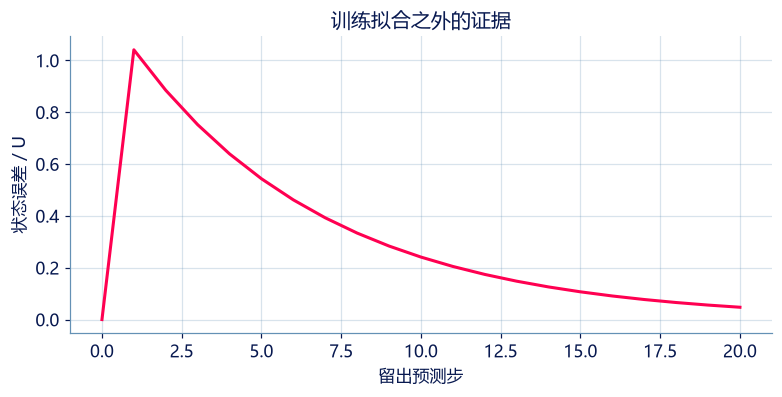

In [4]:
step=np.eye(3)-.05*L
train=np.asarray(linear_roll(step,[2.,1.,0.],40))
truth=np.asarray(linear_roll(step,[3.,0.,0.],20))
estimated=np.asarray(dmd_fit(train[:-1].T,train[1:].T,2))
pred=np.asarray(linear_roll(estimated,[3.,0.,0.],20))
print("训练一步残差",np.linalg.norm(train[1:].T-estimated@train[:-1].T))
print("留出误差/总量差/负值",path_metrics(truth,pred,[1,1,1]))
print("真实结构",structure_metrics(-L,.05))
fig,ax=plt.subplots(figsize=(7,3.5));ax.plot(np.linalg.norm(pred-truth,axis=1),color=PINK);ax.set(xlabel="留出预测步",ylabel="状态误差 / U",title="训练拟合之外的证据");ax.grid(alpha=.25);plt.show()

## 结果解释

训练轨迹没有激发全部三室方向。即使训练一步残差接近零，留出初值的预测仍可能偏离。再检查矩阵的列和、非对角元及一步更新矩阵，就能分别判断守恒、连续正性与 Euler 非负性。

### 独立核对

总量核验来自已知闭合交换；留出误差应确实大于训练一步残差。

In [5]:
np.testing.assert_allclose(truth.sum(axis=1),3.,atol=1e-12)
assert np.linalg.norm(pred-truth)>.1
assert structure_metrics(-L,.05)[3:] == [True,True]
print("独立初值、守恒与结构边界核验通过。")

独立初值、守恒与结构边界核验通过。


## 练习与参考资料

先独立作答，再提交核对。

本篇综合题按基础辨析、方法应用、综合验证、迁移挑战递进，共 100 分。每题独立作答；正确选择或完整测试通过得该题全部分值。网页分别汇总首次作答分与练习达成分，支持按层次和学习目标复习。

### 第 1 题 · 基础辨析 · 10 分 · 单项选择题：投影误差与动态误差

训练快照的秩（rank）1重建误差为0，留出初值（initial condition）有未激发方向。哪项结论成立？

- **A.** 训练重建成功不保证留出轨迹（trajectory）的初态或长期预测。
- **B.** 留出误差必为0。
- **C.** 奇异值（singular value）之和就是长期预测误差。
- **D.** 可以用留出轨迹求基后仍叫原独立测试。

[作答：投影误差与动态误差](http://127.0.0.1:8000/parts/14-%E6%95%B0%E6%8D%AE%E9%A9%B1%E5%8A%A8%E5%8A%A8%E5%8A%9B%E5%AD%A6%E4%B8%8E%E6%A8%A1%E5%9E%8B%E9%99%8D%E9%98%B6/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p14-capstone-projection-claim)

### 第 2 题 · 基础辨析 · 10 分 · 单项选择题：线性提升的保证

一组三项字典在教学三角映射中恰好闭合。对一般新系统能推出什么？

- **A.** 不能直接推出有限字典也闭合，需检查误差与范围。
- **B.** 任意有限字典都精确闭合。
- **C.** 原状态（state）映射一定线性。
- **D.** 训练拟合足以证明因果机制。

[作答：线性提升的保证](http://127.0.0.1:8000/parts/14-%E6%95%B0%E6%8D%AE%E9%A9%B1%E5%8A%A8%E5%8A%A8%E5%8A%9B%E5%AD%A6%E4%B8%8E%E6%A8%A1%E5%9E%8B%E9%99%8D%E9%98%B6/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p14-capstone-lift-limit)

### 第 3 题 · 方法应用 · 15 分 · Python 计算题：综合：低秩投影与重建

给定训练快照和截断秩（rank），返回正交投影（orthogonal projection）、重建矩阵（matrix）与 Frobenius 残差（residual），以供后续模型（model）比较。

**函数与代码模板**

```python
def solve(
    snapshots: list[list[float]],
    rank: int,
) -> tuple[list[list[float]], list[list[float]], float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `snapshots` | `list[list[float]]` | n×m 训练快照。 | U |
| `rank` | `int` | 截断秩。 | 个 |

**返回值**

按以下顺序返回元组：(reconstruction, projection, residual)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `reconstruction` | `list[list[float]]` | 投影（projection）重建矩阵。 | U |
| `projection` | `list[list[float]]` | n×n 正交投影矩阵。 | 1 |
| `residual` | `float` | 训练 Frobenius 残差。 | U |

**计算规则**

不中心化；奇异向量（vector）符号不影响投影。非端点截断有严格奇异值（singular value）间隙；rank=0 返回零投影。

**约束与边界**

- n≥m≥1，快照列满秩，0≤rank≤m；非端点截断处有严格间隙。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| snapshots | n×m 训练快照。 | [[4.0, 0.0], [0.0, 1.0]] | U |
| rank | 截断秩。 | 1 | 个 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
snapshots = [[4.0, 0.0], [0.0, 1.0]]
rank = 1

result = solve(snapshots, rank)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| reconstruction | 投影（projection）重建矩阵。 | [[4.0, 0.0], [0.0, 0.0]] | U |
| projection | n×n 正交投影矩阵。 | [[1.0, 0.0], [0.0, 0.0]] | 1 |
| residual | 训练 Frobenius 残差。 | 1 | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[4.0, 0.0], [0.0, 0.0]],
                   [[1.0, 0.0], [0.0, 0.0]],
                   1.0)
```

**样例解释**

首例保留第一方向，投影重建第二行变0，残差为1 U。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：综合：低秩投影与重建](http://127.0.0.1:8000/parts/14-%E6%95%B0%E6%8D%AE%E9%A9%B1%E5%8A%A8%E5%8A%A8%E5%8A%9B%E5%AD%A6%E4%B8%8E%E6%A8%A1%E5%9E%8B%E9%99%8D%E9%98%B6/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p14-capstone-projection)

### 第 4 题 · 方法应用 · 15 分 · Python 计算题：综合：提升传播及训练残差

固定字典的相邻特征列已给出。按题定岭式回归返回特征传播矩阵（matrix）和训练 Frobenius 残差（residual）。

**函数与代码模板**

```python
def solve(
    feature_past: list[list[float]],
    feature_next: list[list[float]],
    ridge: float,
) -> tuple[list[list[float]], float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `feature_past` | `list[list[float]]` | d×m 旧特征。 | 按特征声明 |
| `feature_next` | `list[list[float]]` | d×m 新特征。 | 按特征声明 |
| `ridge` | `float` | 非负岭参数（parameter）。 | 按特征尺度 |

**返回值**

按以下顺序返回元组：(operator, residual)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `operator` | `list[list[float]]` | d×d 特征传播。 | 按特征尺度 |
| `residual` | `float` | &#124;&#124;Y−KX&#124;&#124;_F。 | 按特征尺度 |

**计算规则**

K 左乘特征列；ridge=0 用 rcond=10⁻¹² 的伪逆（pseudoinverse），ridge>0 用 YXᵀ(XXᵀ+ridge I)⁻¹。训练残差不是独立预测误差。

**约束与边界**

- d,m≥1，矩阵同形，ridge≥0；全部有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| feature_past | d×m 旧特征。 | [[1.0, 0.0], [0.0, 1.0]] | 按特征声明 |
| feature_next | d×m 新特征。 | [[0.8, 0.0], [0.0, 0.6]] | 按特征声明 |
| ridge | 非负岭参数（parameter）。 | 0 | 按特征尺度 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
feature_past = [[1.0, 0.0], [0.0, 1.0]]
feature_next = [[0.8, 0.0], [0.0, 0.6]]
ridge = 0.0

result = solve(feature_past, feature_next, ridge)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| operator | d×d 特征传播。 | [[0.8, 0.0], [0.0, 0.6]] | 按特征尺度 |
| residual | ||Y−KX||_F。 | 0 | 按特征尺度 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[0.8, 0.0], [0.0, 0.6]], 0.0)
```

**样例解释**

首例字典配对构成对角传播，矩阵为 diag(0.8,0.6)，训练残差为0。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：综合：提升传播及训练残差](http://127.0.0.1:8000/parts/14-%E6%95%B0%E6%8D%AE%E9%A9%B1%E5%8A%A8%E5%8A%A8%E5%8A%9B%E5%AD%A6%E4%B8%8E%E6%A8%A1%E5%9E%8B%E9%99%8D%E9%98%B6/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p14-capstone-edmd)

### 第 5 题 · 综合验证 · 15 分 · Python 计算题：综合：稀疏辨识与新状态导数

从题定候选字典和导数（derivative）拟合稀疏系数，并用独立给定的新状态（state）特征预测其导数。

**函数与代码模板**

```python
def solve(
    theta: list[list[float]],
    derivative: list[float],
    threshold: float,
    max_iter: int,
    test_features: list[float],
) -> tuple[list[float], list[int], float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `theta` | `list[list[float]]` | N×p 训练候选字典。 | 按列定义 |
| `derivative` | `list[float]` | 训练导数。 | U/T |
| `threshold` | `float` | 正的归一化系数阈值。 | U/T |
| `max_iter` | `int` | 最多重拟合次数。 | 次 |
| `test_features` | `list[float]` | 未用于拟合的 p 个候选项数值。 | 按列定义 |

**返回值**

按以下顺序返回元组：(coefficients, active, prediction)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `coefficients` | `list[float]` | 原列尺度的系数。 | 按列定义 |
| `active` | `list[int]` | 从0开始的活动列。 | 个 |
| `prediction` | `float` | test_features 与系数的点积。 | U/T |

**计算规则**

归一化、阈值、重拟合和零列规则与 14.4.1 一致；新特征只用于最后计算，不参与选择支持。

**约束与边界**

- N,p≥1，threshold>0，max_iter≥0；全部有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| theta | N×p 训练候选字典。 | [[1.0, 0.0], [0.0, 1.0]] | 按列定义 |
| derivative | 训练导数。 | [0.0, 2.0] | U/T |
| threshold | 正的归一化系数阈值。 | 0.1 | U/T |
| max_iter | 最多重拟合次数。 | 5 | 次 |
| test_features | 未用于拟合的 p 个候选项数值。 | [1.0, 3.0] | 按列定义 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
theta = [[1.0, 0.0], [0.0, 1.0]]
derivative = [0.0, 2.0]
threshold = 0.1
max_iter = 5
test_features = [1.0, 3.0]

result = solve(theta, derivative, threshold, max_iter, test_features)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| coefficients | 原列尺度的系数。 | [0.0, 2.0] | 按列定义 |
| active | 从0开始的活动列。 | [1] | 个 |
| prediction | test_features 与系数的点积。 | 6 | U/T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.0, 2.0], [1], 6.0)
```

**样例解释**

首例只有第二项活动，独立新特征 [1,3] 给出的导数预测为6。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：综合：稀疏辨识与新状态导数](http://127.0.0.1:8000/parts/14-%E6%95%B0%E6%8D%AE%E9%A9%B1%E5%8A%A8%E5%8A%A8%E5%8A%9B%E5%AD%A6%E4%B8%8E%E6%A8%A1%E5%9E%8B%E9%99%8D%E9%98%B6/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p14-capstone-sparse)

### 第 6 题 · 综合验证 · 15 分 · Python 计算题：综合：外推误差与结构失败

比较同一评估轨迹（trajectory）下的真值与候选预测，返回 RMSE、加权总量最大差及负值数；失败时刻不能删去。

**函数与代码模板**

```python
def solve(
    truth: list[list[float]],
    prediction: list[list[float]],
    weights: list[float],
) -> tuple[float, float, int]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `truth` | `list[list[float]]` | N×n 留出真值。 | U |
| `prediction` | `list[list[float]]` | N×n 候选预测。 | U |
| `weights` | `list[float]` | n 个守恒权重。 | 1 |

**返回值**

按以下顺序返回元组：(rmse, max_balance, negatives)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `rmse` | `float` | 逐元素均方根误差（root mean squared error，RMSE）。 | U |
| `max_balance` | `float` | 相对于真值的加权总量差最大值。 | U |
| `negatives` | `int` | 低于 −10⁻¹⁰ 的预测元素数。 | 个 |

**计算规则**

三项指标各自报告，不把低 RMSE 自动解释为结构保持。

**约束与边界**

- N,n≥1，矩阵（matrix）同形，权重长度 n；全部有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| truth | N×n 留出真值。 | [[1.0, 1.0], [1.0, 1.0]] | U |
| prediction | N×n 候选预测。 | [[1.0, 1.0], [1.1, 0.9]] | U |
| weights | n 个守恒权重。 | [1.0, 1.0] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
truth = [[1.0, 1.0], [1.0, 1.0]]
prediction = [[1.0, 1.0], [1.1, 0.9]]
weights = [1.0, 1.0]

result = solve(truth, prediction, weights)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| rmse | 逐元素均方根误差（root mean squared error，RMSE）。 | ≈ 0.07071068 | U |
| max_balance | 相对于真值的加权总量差最大值。 | 1.110223e-16 | U |
| negatives | 低于 −10⁻¹⁰ 的预测元素数。 | 0 | 个 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (0.07071067811865477,
                   1.1102230246251565e-16,
                   0)
```

**样例解释**

首例总量差仍为0，但逐室存在预测误差。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：综合：外推误差与结构失败](http://127.0.0.1:8000/parts/14-%E6%95%B0%E6%8D%AE%E9%A9%B1%E5%8A%A8%E5%8A%A8%E5%8A%9B%E5%AD%A6%E4%B8%8E%E6%A8%A1%E5%9E%8B%E9%99%8D%E9%98%B6/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p14-capstone-structure)

### 第 7 题 · 迁移挑战 · 10 分 · 单项选择题：噪声下选择方程

导数（derivative）噪声下多个稀疏方程训练拟合接近，应怎样选择与检验？

- **A.** 用预先独立的验证轨迹（trajectory）选阈值，保留最后未参与选择的测试轨迹。
- **B.** 只选训练残差（residual）最低且最漂亮的曲线。
- **C.** 把测试轨迹用于反复调参后仍称独立测试。
- **D.** 一次稀疏支持足以证明真实机制。

[作答：噪声下选择方程](http://127.0.0.1:8000/parts/14-%E6%95%B0%E6%8D%AE%E9%A9%B1%E5%8A%A8%E5%8A%A8%E5%8A%9B%E5%AD%A6%E4%B8%8E%E6%A8%A1%E5%9E%8B%E9%99%8D%E9%98%B6/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p14-capstone-noisy-selection)

### 第 8 题 · 迁移挑战 · 10 分 · 单项选择题：新输入后的结论边界

训练只含无外部输入（input）交换，新条件增加了时变输入。哪项结论合理？

- **A.** 原无输入模型（model）未编码该输入作用，须扩展模型并用独立输入条件检验。
- **B.** 训练重建误差小保证新输入预测。
- **C.** 把新输入实验拿来拟合后仍报告为原独立测试。
- **D.** 绘图更平滑可代替新实验条件。

[作答：新输入后的结论边界](http://127.0.0.1:8000/parts/14-%E6%95%B0%E6%8D%AE%E9%A9%B1%E5%8A%A8%E5%8A%A8%E5%8A%9B%E5%AD%A6%E4%B8%8E%E6%A8%A1%E5%9E%8B%E9%99%8D%E9%98%B6/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p14-capstone-new-input)

**进一步阅读**

[第 14 篇设计与参考映射](../../../docs/14-数据驱动动力学与模型降阶.md)。